Dane startowe — pierwsza komórka notebooka

In [2]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
# Globalny motyw — raz, na początku notebooka
sns.set_theme(style='whitegrid', palette='muted')
# Dataset tips — restauracja, 244 rachunki (znany z W09)
tips = sns.load_dataset('tips')
print(f"Tips dataset: {tips.shape[0]} wierszy × {tips.shape[1]} kolumn")
print(f"Kolumny: {list(tips.columns)}")
tips.head(3)

Tips dataset: 244 wierszy × 7 kolumn
Kolumny: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


Ćwiczenie 1: Statystyczne wykresy seaborn (20 min)

Zadanie 1.1 — Barplot z hue (wzór do skopiowania)

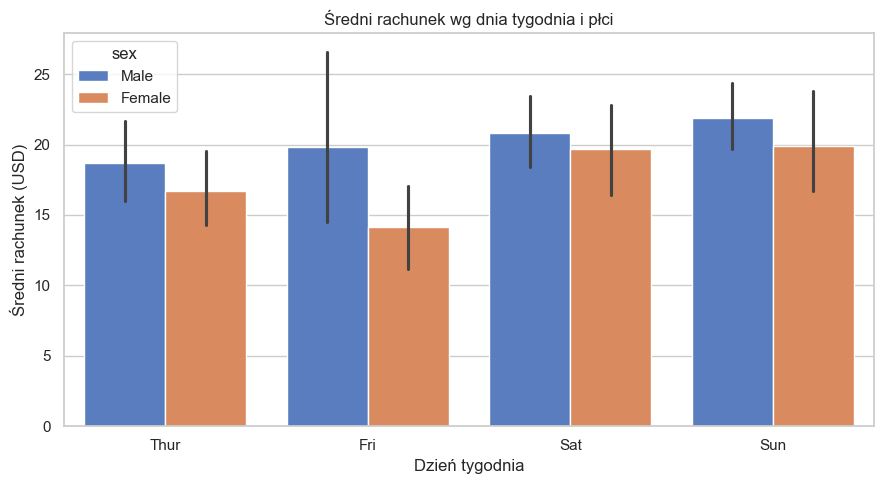

Zapisano: barplot_dzien_plec.png


In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
data=tips,
x='day',
y='total_bill',
hue='sex',
ax=ax,
palette='muted',
errorbar=('ci', 95), # 95% CI = przedział ufności średniej
)
ax.set_title('Średni rachunek wg dnia tygodnia i płci')
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Średni rachunek (USD)')
plt.tight_layout()
plt.savefig('barplot_dzien_plec.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: barplot_dzien_plec.png")

Zadanie 1.2 — Boxplot (uzupełnij ???)

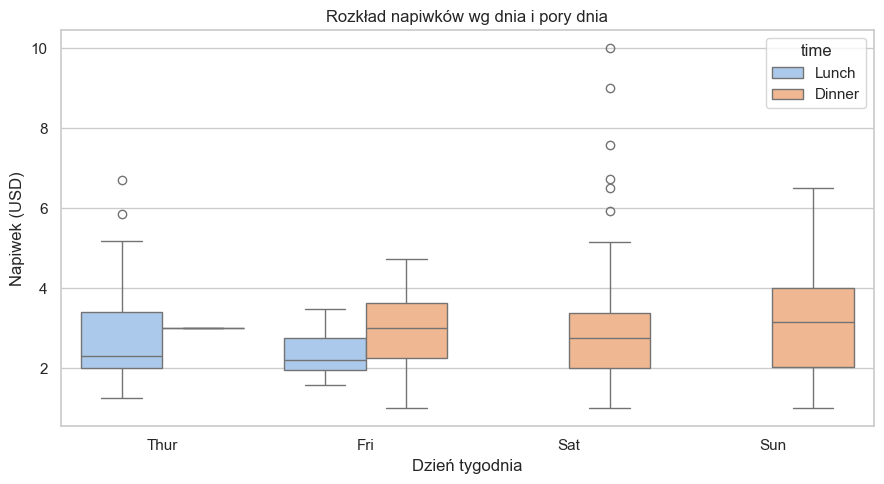

Zapisano: boxplot_napiwki.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
data=tips,
x=tips['day'], y=tips['tip'], ax=ax,
palette='pastel',
# kolumna kategoryczna na oś X (Thur/Fri/Sat/Sun)
# kolumna numeryczna na oś Y (napiwek)
hue=tips['time'], # podział kolorystyczny (Lunch/Dinner)
)
ax.set_title('Rozkład napiwków wg dnia i pory dnia')
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Napiwek (USD)')
plt.tight_layout()
plt.savefig('boxplot_napiwki.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: boxplot_napiwki.png")

Zadanie 1.3 — Heatmap korelacji (uzupełnij ???)

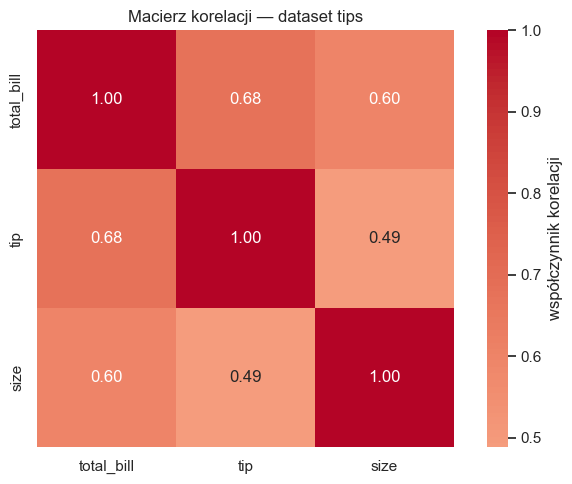

Zapisano: heatmap_korelacja.png


In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
# Korelacja tylko zmiennych numerycznych
corr = tips.select_dtypes('number').corr()
sns.heatmap(
corr,
annot=True, fmt='.2f', cmap='coolwarm',
center=0, ax=ax,
square=True,
cbar_kws={'label': 'współczynnik korelacji'},)
ax.set_title('Macierz korelacji — dataset tips')
plt.tight_layout()
plt.savefig('heatmap_korelacja.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: heatmap_korelacja.png")

Zadanie 1.4 — Scatter z hue + style (samodzielnie)

kolor punktu zależy od 'smoker' (Yes/No)

kształt markera zależy od 'time' (Lunch/Dinner)

punkty są lekko przezroczyste (alpha)

tytuł, etykiety osi z jednostkami (USD)

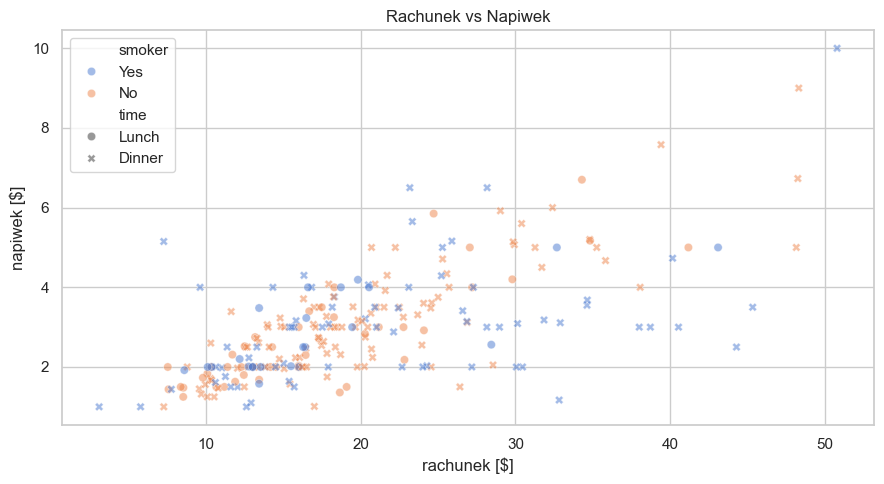

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=tips, x=tips['total_bill'], y=tips['tip'], hue=tips['smoker'], style=tips['time'], alpha=0.5)
ax.set_title('Rachunek vs Napiwek')
ax.set_xlabel('rachunek [$]')
ax.set_ylabel('napiwek [$]')
plt.tight_layout()
plt.savefig('scatter_rachunek_napiwek.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()

Ćwiczenie 2: Subplots, GridSpec, shared axes (20 min)

Zadanie 2.1 — Regularna siatka 2×2
Cztery wykresy z datasetu tips na jednej figurze

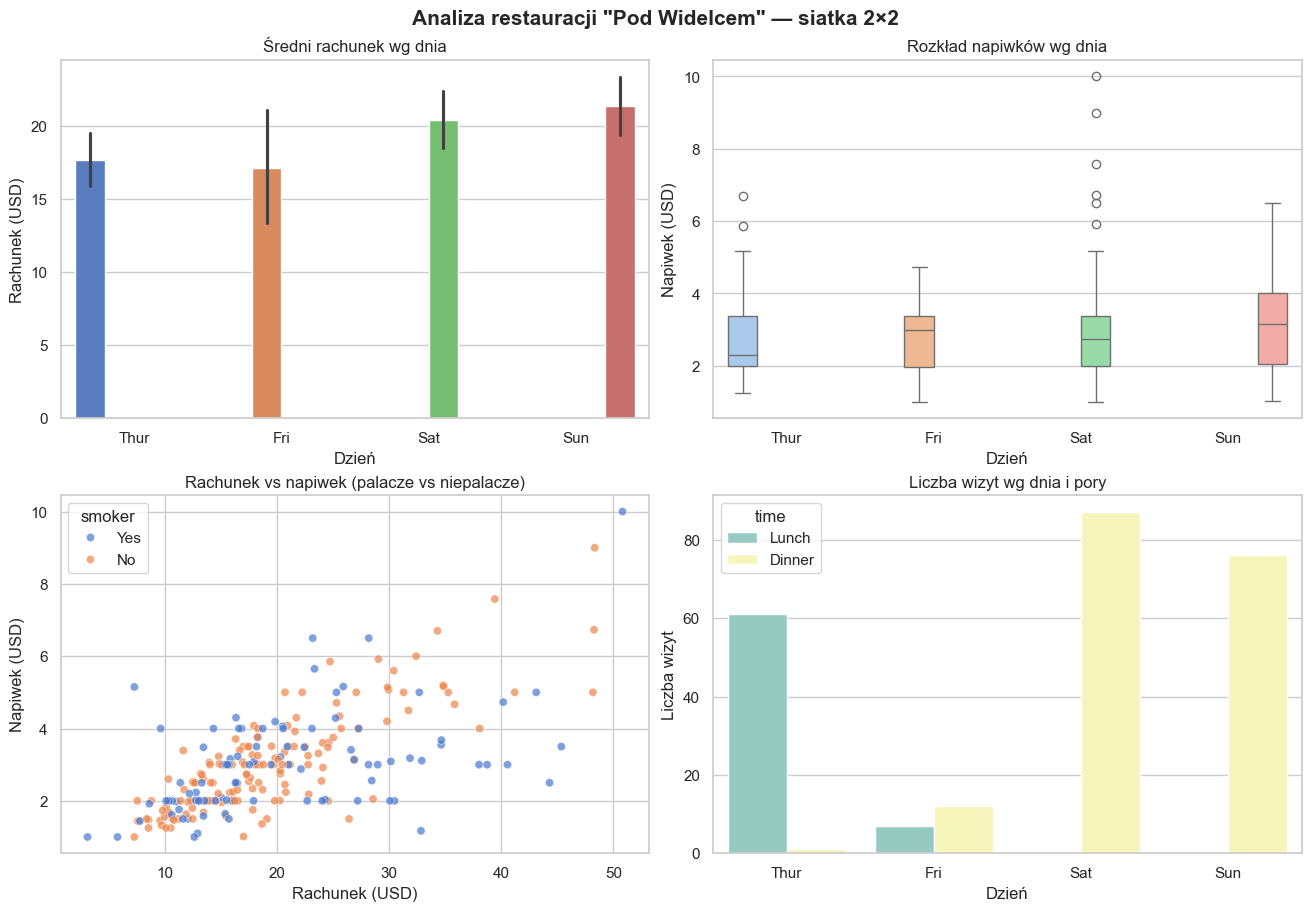

Zapisano: siatka_2x2.png


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
# Panel [0, 0] — barplot (gotowy wzór)
sns.barplot(data=tips, x='day', y='total_bill', hue='day', legend=False,
ax=axes[0, 0], palette='muted', errorbar=('ci', 95))
axes[0, 0].set_title('Średni rachunek wg dnia')
axes[0, 0].set_xlabel('Dzień')
axes[0, 0].set_ylabel('Rachunek (USD)')
# Panel [0, 1] — boxplot (uzupełnij)
sns.boxplot(
data=tips,
x='day', # 'day'
y='tip', # 'tip'
hue='day', legend=False,
ax=axes[0, 1],
palette='pastel',
)
axes[0, 1].set_title('Rozkład napiwków wg dnia')
axes[0, 1].set_xlabel('Dzień')
axes[0, 1].set_ylabel('Napiwek (USD)')
# Panel [1, 0] — scatter (uzupełnij)
sns.scatterplot(
data=tips,
x='total_bill', # 'total_bill'
y='tip', # 'tip'
hue='smoker',
alpha=0.7,
ax=axes[1, 0],
)
axes[1, 0].set_title('Rachunek vs napiwek (palacze vs niepalacze)')
axes[1, 0].set_xlabel('Rachunek (USD)')
axes[1, 0].set_ylabel('Napiwek (USD)')
# Panel [1, 1] — countplot (uzupełnij)
sns.countplot(
data=tips,
x='day', # 'day'
hue='time',
ax=axes[1, 1],
palette='Set3',
)
axes[1, 1].set_title('Liczba wizyt wg dnia i pory')
axes[1, 1].set_xlabel('Dzień')
axes[1, 1].set_ylabel('Liczba wizyt')
fig.suptitle('Analiza restauracji "Pod Widelcem" — siatka 2×2',
fontsize=15, fontweight='bold')
plt.savefig('siatka_2x2.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: siatka_2x2.png")

Zadanie 2.2 — GridSpec — nieregularny dashboard

Stwórz Figure z GridSpec(2, 2) w której górny rząd to jeden panel (pełna szerokość), a dolny rząd ma 2
panele.

In [18]:
pivot = tips.pivot_table(values='tip', # wartości w komórkach
index='day', # wiersze
columns='time', # kolumny
aggfunc='mean', # jaka statystyka
observed=True) # ważne dla kategorii
# Wynik: macierz 4×2 (dni × pora), każda komórka = średni napiwek

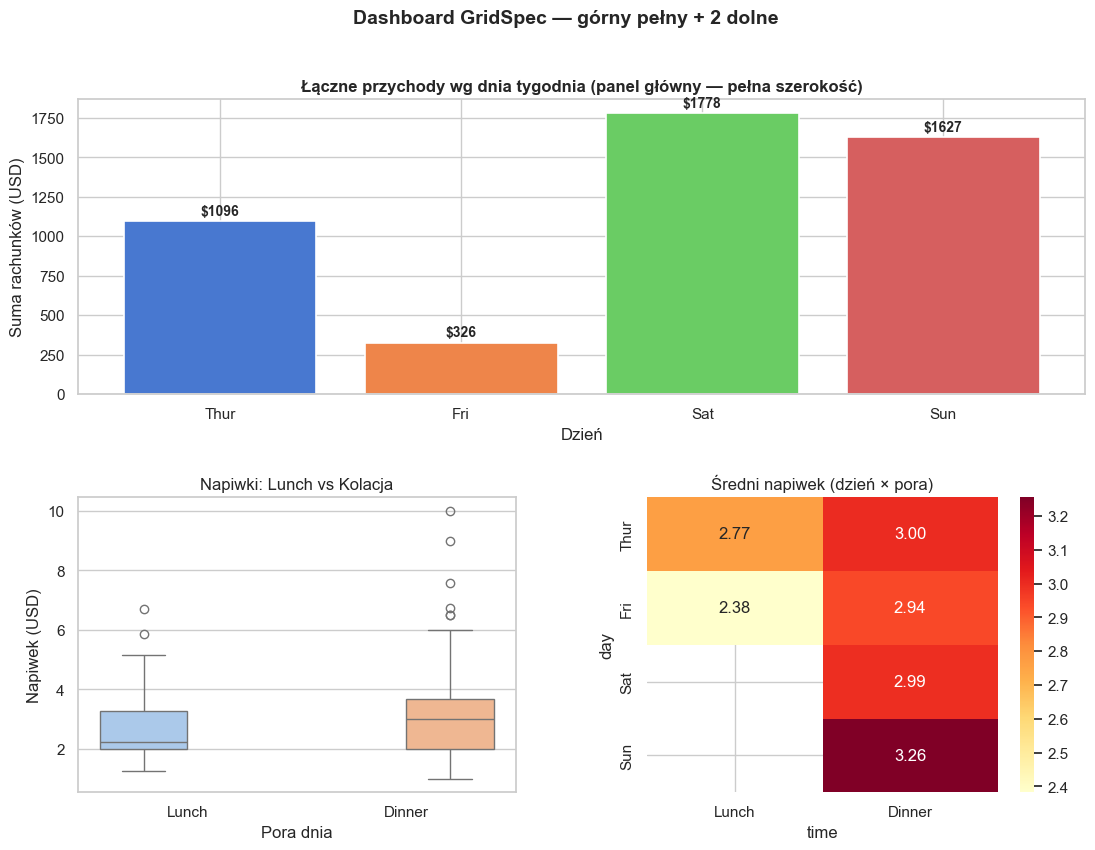

Zapisano: gridspec_dashboard.png


In [29]:
fig = plt.figure(figsize=(13, 9))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)
# Górny — pełna szerokość: barplot suma rachunków per dzień
ax_top = fig.add_subplot(gs[0, :])
tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()
ax_top.bar(
tips_sum['day'].astype(str),
tips_sum['total_bill'],
color=sns.color_palette('muted')[:4],
edgecolor='white', linewidth=1.2,)
# Dodaj wartości nad słupkami
for i, val in enumerate(tips_sum['total_bill']):
    ax_top.text(i, val + 20, f'${val:.0f}',
    ha='center', va='bottom', fontsize=10, fontweight='bold')

ax_top.set_title('Łączne przychody wg dnia tygodnia (panel główny — pełna szerokość)', fontsize=12, fontweight='bold')
ax_top.set_xlabel('Dzień')
ax_top.set_ylabel('Suma rachunków (USD)')
# Dolny lewy — boxplot Lunch vs Dinner (uzupełnij)
ax_bl = fig.add_subplot(gs[1, 0])
sns.boxplot(
data=tips,
x='time', # 'time'
y='tip', # 'tip'
hue='time', legend=False,
ax=ax_bl,
palette='pastel',
)
ax_bl.set_title('Napiwki: Lunch vs Kolacja')
ax_bl.set_xlabel('Pora dnia')
ax_bl.set_ylabel('Napiwek (USD)')
# Dolny prawy — heatmap pivot (samodzielnie)
# Cel: stwórz pivot_table — wiersze=day, kolumny=time, wartości=mean(tip)
# Zwizualizuj jako heatmap z annot=True, fmt='.2f', cmap='YlOrRd'
ax_br = fig.add_subplot(gs[1, 1])
# Twój kod:
pivot = tips.pivot_table(values='tip',index='day',columns='time', aggfunc='mean', observed=True)
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd')
ax_br.set_title('Średni napiwek (dzień × pora)')
fig.suptitle('Dashboard GridSpec — górny pełny + 2 dolne',
fontsize=14, fontweight='bold')
plt.savefig('gridspec_dashboard.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: gridspec_dashboard.png")

Zadanie 2.3 — Shared axes (samodzielnie)

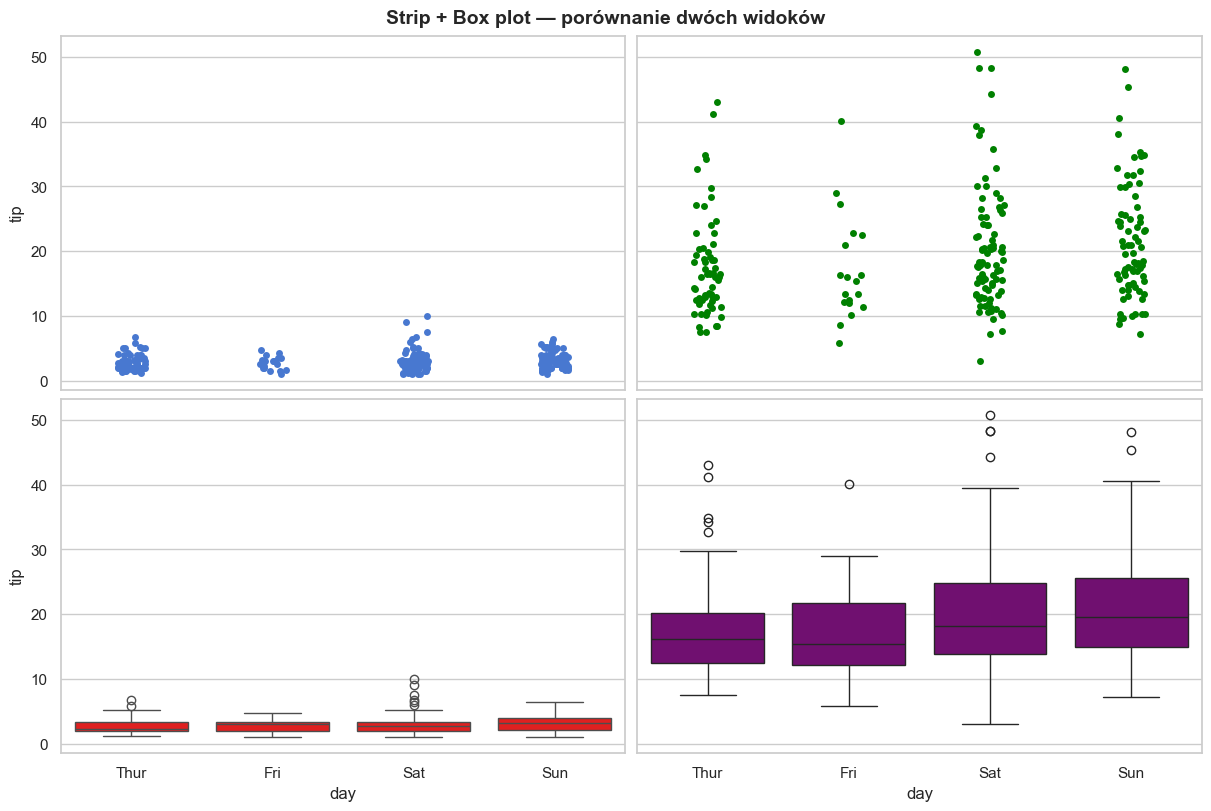

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8),
sharex='col', sharey='row',
constrained_layout=True)
# Twój kod — 4 wykresy
sns.stripplot(data=tips, x='day', y=tips['tip'], ax = axes[0,0])

sns.boxplot(data=tips, x='day', y=tips['tip'], ax = axes[1,0], color='red')

sns.stripplot(data=tips, x='day', y=tips['total_bill'], ax = axes[0,1], color='green')

sns.boxplot(data=tips, x='day', y=tips['total_bill'], ax = axes[1,1], color = 'purple')
fig.suptitle('Strip + Box plot — porównanie dwóch widoków',
fontsize=14, fontweight='bold')
plt.savefig('shared_axes.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

Ćwiczenie 3: Pełny dashboard analityczny (30 min) — praca samodzielna

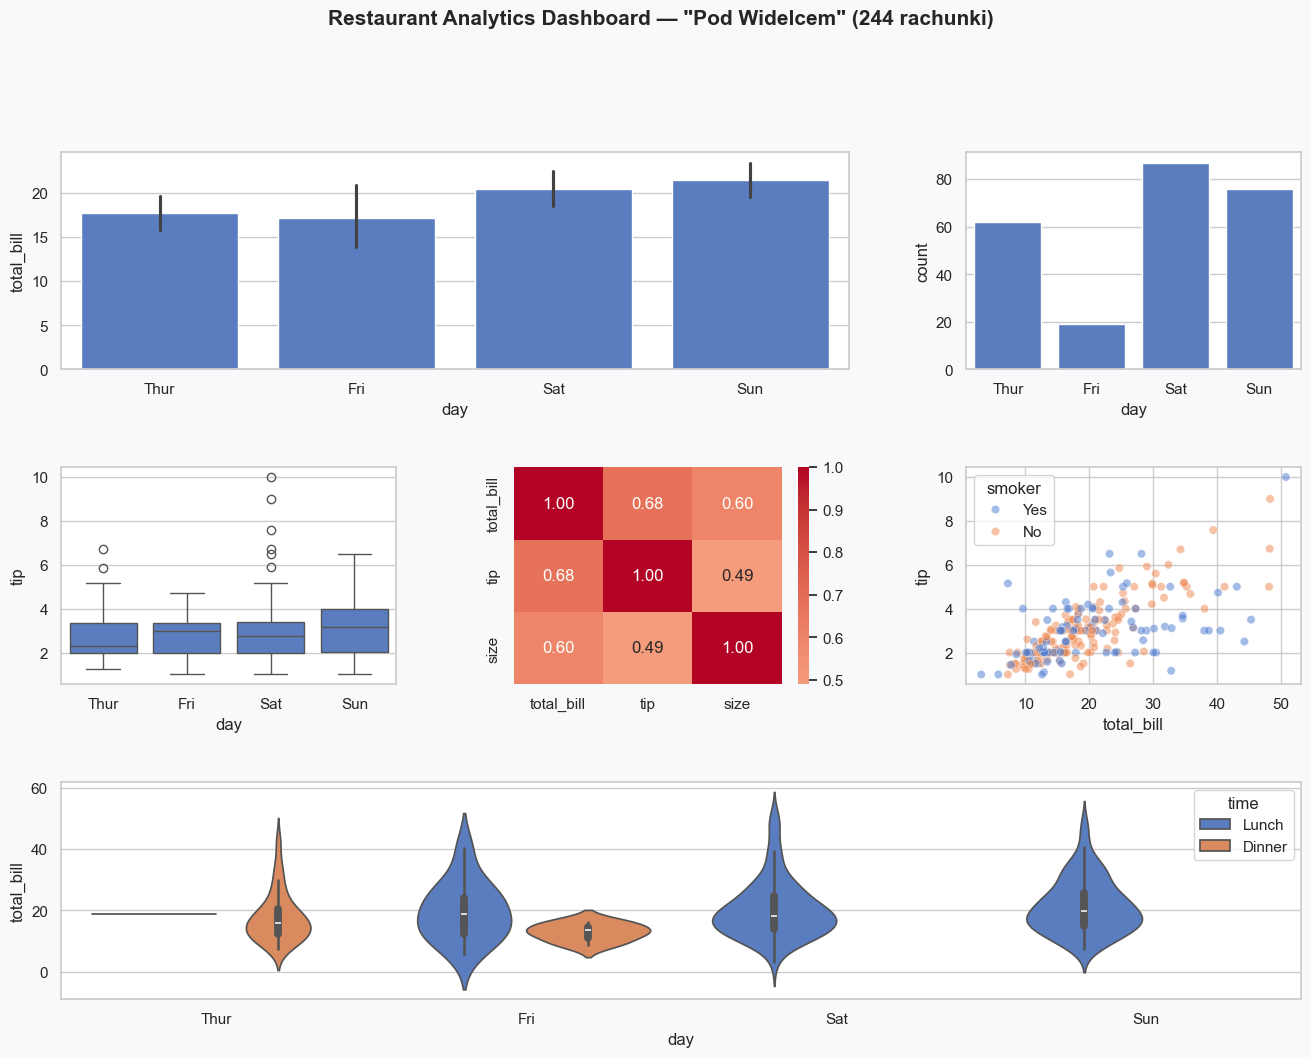

Zapisano: dashboard_pod_widelcem.png


In [54]:
# Restaurant Analytics Dashboard "Pod Widelcem"
fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor('#f8f9fa') # tło figury — jasnoszare
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
# === PANEL 1 (KPI główny): łączne przychody per dzień (gs[0, :2]) ===
ax1 = fig.add_subplot(gs[0, :2])
sns.barplot(data=tips, x='day', y='total_bill', ax = ax1)
# Twój kod — barplot z etykietami wartości nad słupkami
# === PANEL 2: udział wizyt per dzień (gs[0, 2]) ===
ax2 = fig.add_subplot(gs[0, 2])
sns.countplot(data=tips, x='day', ax = ax2)
# Twój kod — pie chart lub countplot
# === PANEL 3: rozkład napiwków (gs[1, 0]) ===
ax3 = fig.add_subplot(gs[1, 0])
sns.boxplot(data=tips, x='day', y='tip', ax = ax3)
# Twój kod — boxplot napiwki per dzień
# === PANEL 4: heatmap korelacji (gs[1, 1]) ===
ax4 = fig.add_subplot(gs[1, 1])
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax4)
# Twój kod — sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
# === PANEL 5: scatter (gs[1, 2]) ===
ax5 = fig.add_subplot(gs[1, 2])
sns.scatterplot(data=tips, x=tips['total_bill'], y=tips['tip'], hue=tips['smoker'], alpha=0.5, ax=ax5)
# Twój kod — sns.scatterplot rachunek vs napiwek z hue='smoker'
# === PANEL 6 (sumaryczny): rozkład rachunków (gs[2, :]) ===
ax6 = fig.add_subplot(gs[2, :])
sns.violinplot(data=tips, x='day', y='total_bill', hue='time', ax = ax6)
# Twój kod — sns.violinplot rachunki per dzień z hue='time', split=True
fig.suptitle('Restaurant Analytics Dashboard — "Pod Widelcem" (244 rachunki)',
fontsize=15, fontweight='bold', y=1.01)
plt.savefig('dashboard_pod_widelcem.png',
dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: dashboard_pod_widelcem.png")

Ćwiczenie 4: Style, eksport, adnotacja, commit (15 min)

Zadanie 4.1 — Porównanie stylów seaborn (5 min)

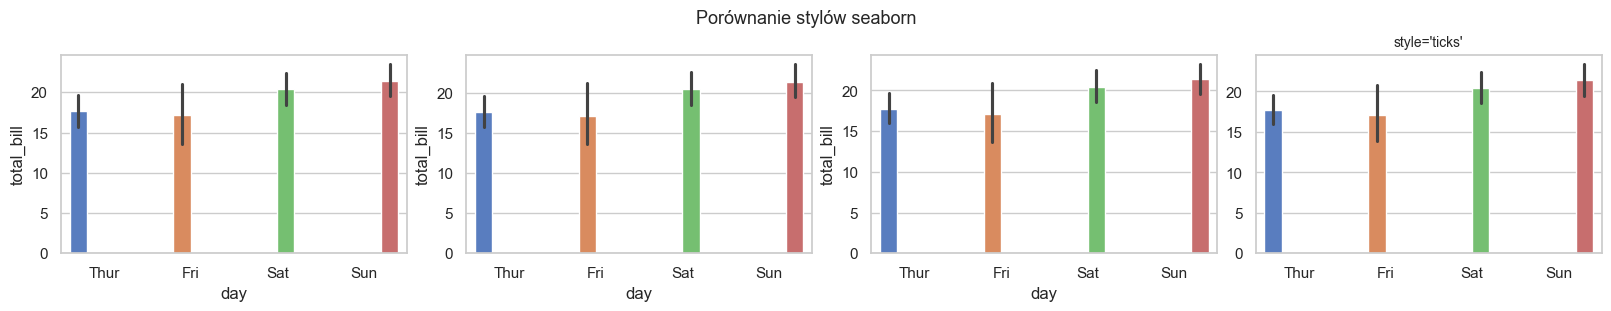

In [55]:
styles = ['whitegrid', 'darkgrid', 'white', 'ticks']
fig, axes = plt.subplots(1, 4, figsize=(16, 3), constrained_layout=True)
for ax, style in zip(axes, styles):
    with sns.axes_style(style): # context manager — tymczasowo zmień styl
        sns.barplot(data=tips, x='day', y='total_bill', hue='day', legend=False,
                    ax=ax, palette='muted')
ax.set_title(f"style='{style}'", fontsize=10)
ax.set_xlabel('')
ax.set_ylabel('Rachunek' if ax is axes[0] else '')
fig.suptitle('Porównanie stylów seaborn', fontsize=13)
plt.savefig('porownanie_stylow.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()

Zadanie 4.2 — Adnotacja na wykresie (5 min)

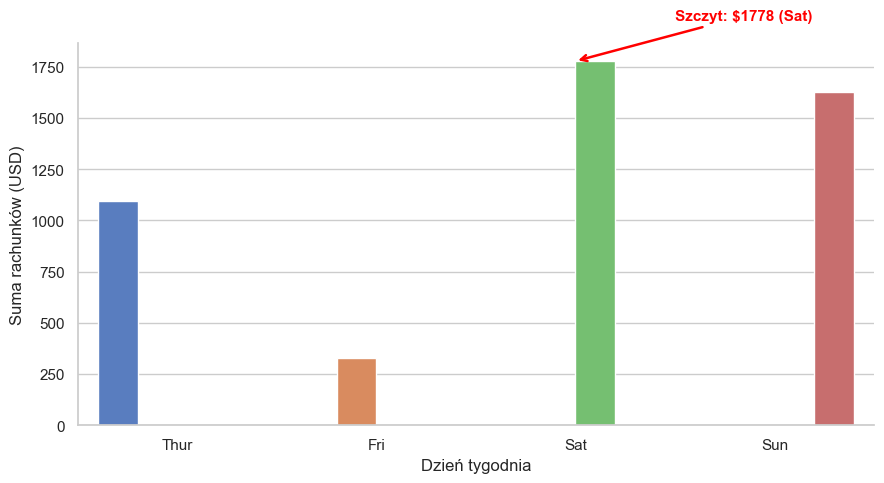

Zapisano: szczyt_przychodow.png


In [59]:
fig, ax = plt.subplots(figsize=(9, 5))
tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()
sns.barplot(data=tips_sum, x='day', y='total_bill', hue='day', legend=False,
ax=ax, palette='muted')
# Znajdź szczyt
max_idx = tips_sum['total_bill'].idxmax()
max_day = tips_sum.loc[max_idx, 'day']
max_val = tips_sum.loc[max_idx, 'total_bill']
# Adnotacja ze strzałką
ax.annotate(
f'Szczyt: ${max_val:.0f} ({max_day})',
xy=(max_idx, max_val), # punkt na który wskazuje strzałka — (max_idx,max_val)
xytext=(max_idx + 0.5, max_val + 200), # gdzie tekst — (max_idx + 0.5, max_val + 200)
arrowprops=dict(arrowstyle='->', color='red', lw=1.8),
fontsize=11, color='red', fontweight='bold',
)
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Suma rachunków (USD)')
sns.despine()
plt.tight_layout()
plt.savefig('szczyt_przychodow.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: szczyt_przychodow.png")